In [2]:
!pip install keras.optimizer

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
ERROR: Could not find a version that satisfies the requirement keras.optimizer (from versions: none)
ERROR: No matching distribution found for keras.optimizer


In [3]:
import numpy as np
import pandas as pd
import os
import librosa
import wave
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

import keras
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import RMSprop
print()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
def extract_mfcc(wav_file_name):
  y,sr = librosa.load(wav_file_name)
  mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T,axis=0)

  return mfccs

In [6]:
ravdess_speech_labels = []
ravdess_speech_data = []
for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab Notebooks/ravdess-emotional-speech-audio/'):
  for filename in filenames:
    ravdess_speech_labels.append(int(filename[7:8])-1)
    wav_file_name = os.path.join(dirname,filename)
    ravdess_speech_data.append(extract_mfcc(wav_file_name))

print("Finish Loading the Dataset")

Finish Loading the Dataset


In [7]:
ravdess_speech_data

[array([-5.6616028e+02,  4.0987202e+01, -1.4152069e+01, -4.0712562e+00,
        -8.2691278e+00, -7.1202874e+00, -1.5157016e+01, -8.1430140e+00,
        -1.7001905e+01,  2.7189205e+00, -6.7432837e+00, -8.5935631e+00,
        -6.0137882e+00, -5.6177521e+00, -3.0749757e+00, -4.4637814e+00,
        -5.8740153e+00,  3.1492522e+00, -3.2051456e+00,  2.0914288e+00,
        -1.7963293e+00,  1.6578258e+00, -1.6369069e+00,  4.2193546e+00,
        -2.5208890e+00,  2.5768616e+00, -3.2236912e+00,  3.0768640e+00,
        -9.7594202e-01,  3.5999055e+00, -7.4281788e-01,  2.5905516e+00,
         1.7972944e+00,  5.7174015e+00,  6.0345197e-01,  3.3457091e+00,
        -4.0974674e-01,  4.7391546e-01, -2.3482296e+00,  2.2918139e+00],
       dtype=float32),
 array([-6.8757397e+02,  6.2221375e+01, -1.0023206e+01,  5.4676723e+00,
        -2.0519180e+00,  4.6192713e+00, -7.8304863e+00, -8.2899590e+00,
        -1.2783929e+01,  3.2877057e+00, -3.9948473e+00, -6.7325153e+00,
        -4.2925806e+00,  9.3060166e-01, 

In [8]:
# convert data and label to array
ravdess_speech_data_array = np.array(ravdess_speech_data)
ravdess_speech_label_array = np.array(ravdess_speech_labels)
ravdess_speech_label_array.shape

# make categorical labels
labels_categorical = to_categorical(ravdess_speech_label_array)
labels_categorical.shape

(2917, 8)

In [9]:
ravdess_speech_data_array

array([[-5.6616028e+02,  4.0987202e+01, -1.4152069e+01, ...,
         4.7391546e-01, -2.3482296e+00,  2.2918139e+00],
       [-6.8757397e+02,  6.2221375e+01, -1.0023206e+01, ...,
         4.2696171e+00, -1.3304762e+00,  3.4322689e+00],
       [-5.2872241e+02,  4.2204166e+01, -1.9211369e+01, ...,
         2.3460536e+00, -1.3531607e-01,  1.5182501e+00],
       ...,
       [-5.8674976e+02,  5.6366329e+01, -9.1544609e+00, ...,
        -3.1257129e+00, -3.0137923e-01,  3.5071034e+00],
       [-6.0755029e+02,  7.0287987e+01,  1.4846961e-01, ...,
        -3.9210253e+00, -2.7860420e+00,  2.7946274e+00],
       [-5.6027124e+02,  5.4752197e+01, -5.6639256e+00, ...,
        -8.8380384e-01, -3.5816562e+00, -1.9929854e+00]], dtype=float32)

In [10]:
ravdess_speech_data_array.shape

(2917, 40)

In [11]:
x_train,x_test,y_train,y_test = train_test_split(np.array(ravdess_speech_data_array),labels_categorical,test_size=0.20,random_state=9)

In [12]:
# split the training, validating, and testing sets
number_of_samples = ravdess_speech_data_array.shape[0]
training_samples = int(number_of_samples * 0.8)
validation_samples = int(number_of_samples * 0.1)
test_samples = int(number_of_samples * 0.1)

In [13]:
# Define the LSTM model
def create_model_LSTM():
  model = Sequential()
  model.add(LSTM(128,return_sequences=False,input_shape=(40,1)))
  model.add(Dense(64))
  model.add(Dropout(0.4))
  model.add(Activation('relu'))
  model.add(Dense(32))
  model.add(Dropout(0.4))
  model.add(Activation('relu'))
  model.add(Dense(8))
  model.add(Activation('softmax'))

  # configures the model for training
  model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
  return model

In [14]:
w = np.expand_dims(ravdess_speech_data_array[:training_samples],-1)

In [15]:
w.shape

(2333, 40, 1)

In [16]:
# train using LSTM model
model_A = create_model_LSTM()
history = model_A.fit(np.expand_dims(ravdess_speech_data_array[:training_samples],-1),labels_categorical[:training_samples],validation_data=(np.expand_dims(ravdess_speech_data_array[training_samples:training_samples+validation_samples],-1),labels_categorical[training_samples:training_samples+validation_samples]),epochs=130,shuffle=True)

Epoch 1/130
73/73 [==============================] - 8s 74ms/step - loss: 2.0630 - accuracy: 0.1526 - val_loss: 2.0242 - val_accuracy: 0.1718
Epoch 2/130
73/73 [==============================] - 4s 57ms/step - loss: 2.0022 - accuracy: 0.1980 - val_loss: 1.9520 - val_accuracy: 0.2405
Epoch 3/130
73/73 [==============================] - 5s 66ms/step - loss: 1.9477 - accuracy: 0.2499 - val_loss: 1.9429 - val_accuracy: 0.2371
Epoch 4/130
73/73 [==============================] - 6s 77ms/step - loss: 1.9124 - accuracy: 0.2645 - val_loss: 1.8781 - val_accuracy: 0.2955
Epoch 5/130
73/73 [==============================] - 6s 82ms/step - loss: 1.9096 - accuracy: 0.2615 - val_loss: 1.9311 - val_accuracy: 0.2646
Epoch 6/130
73/73 [==============================] - 7s 93ms/step - loss: 1.8758 - accuracy: 0.2790 - val_loss: 1.8636 - val_accuracy: 0.2818
Epoch 7/130
73/73 [==============================] - 6s 86ms/step - loss: 1.8590 - accuracy: 0.2743 - val_loss: 1.8141 - val_accuracy: 0.3093
Epoch 

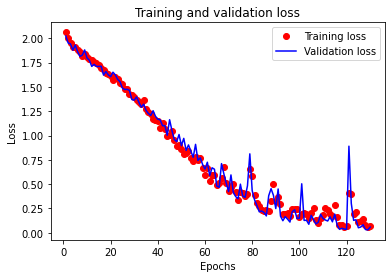

In [17]:
# loss plots using LSTM model
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss)+1)

plt.plot(epochs,loss,'ro',label='Training loss')
plt.plot(epochs,val_loss,'b',label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

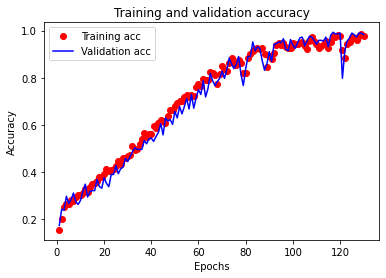

In [19]:
# accuracy plots using LSTM model
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs,acc,'ro',label='Training acc')
plt.plot(epochs,val_acc,'b',label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [20]:
# evaluate using model A
model_A.evaluate(np.expand_dims(ravdess_speech_data_array[training_samples + validation_samples:],-1),labels_categorical[training_samples + validation_samples:])


10/10 [==============================] - 0s 21ms/step - loss: 0.0566 - accuracy: 0.9829


[0.056565672159194946, 0.9829351305961609]

In [21]:
emotions={1:'neutral',2:'calm',3:'happy',4:'sad',5:'angry',6:'fearful',7:'disgust',8:'surprised'}
def predict(wav_filepath):
  test_point = extract_mfcc(wav_filepath)
  test_point = np.reshape(test_point,newshape=(1,40,1))
  predictions = model_A.predict(test_point)
  print(emotions[np.argmax(predictions[0])+1])

In [22]:
predict('/content/drive/MyDrive/Colab Notebooks/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav')

1/1 [==============================] - 1s 542ms/step
neutral


In [23]:
predict('/content/drive/MyDrive/Colab Notebooks/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav')

1/1 [==============================] - 0s 35ms/step
surprised


In [24]:
predict('/content/drive/MyDrive/Colab Notebooks/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav')

1/1 [==============================] - 0s 26ms/step
happy


In [25]:
predict('/content/drive/MyDrive/Colab Notebooks/ravdess-emotional-speech-audio/Actor_13/03-01-01-01-01-02-13.wav')

1/1 [==============================] - 0s 25ms/step
neutral


In [26]:
model_A.save('mymodel.h5')

In [27]:
modelc=tf.keras.models.load_model('mymodel.h5')